## Detect change

This example will demonstrate how to detect change between two timesteps using Kanop's [Screening](https://docs.cecil.earth/Screening-111ef16bbbe481a780bce4de81a500a5) dataset.

The same approach can be used on any dataset that you have requested. Just use one of your own data request ids and swap out variable names as necessary. 

First we set up the Cecil client and import all the required packages.

In [ ]:
import cecil
import xarray
import matplotlib.pyplot as plt

client = cecil.Client()

In [2]:
ds = client.load_xarray('4daa800e-229e-4ba1-9938-8bcdb9f44bc7')
ds

<xarray.Dataset> Size: 7MB
Dimensions:                      (x: 123, y: 78, time: 11)
Coordinates:
  * x                            (x) float64 984B -91.56 -91.56 ... -91.53
  * y                            (y) float64 624B 31.97 31.97 ... 31.95 31.95
    spatial_ref                  int64 8B 0
  * time                         (time) datetime64[ns] 88B 2013-07-01 ... 202...
Data variables:
    tree_height                  (time, y, x) float64 844kB dask.array<chunksize=(1, 78, 123), meta=np.ndarray>
    canopy_cover                 (time, y, x) float64 844kB dask.array<chunksize=(1, 78, 123), meta=np.ndarray>
    canopy_height                (time, y, x) float64 844kB dask.array<chunksize=(1, 78, 123), meta=np.ndarray>
    forest_cover                 (time, y, x) float32 422kB dask.array<chunksize=(1, 78, 123), meta=np.ndarray>
    living_aboveground_biomass   (time, y, x) float64 844kB dask.array<chunksize=(1, 78, 123), meta=np.ndarray>
    living_belowground_biomass   (time, y, x) float64 844kB dask.array<chunksize=(1, 78, 123), meta=np.ndarray>
    living_biomass_co2_eq        (time, y, x) float64 844kB dask.array<chunksize=(1, 78, 123), meta=np.ndarray>
    living_biomass_carbon_stock  (time, y, x) float64 844kB dask.array<chunksize=(1, 78, 123), meta=np.ndarray>
    living_biomass               (time, y, x) float64 844kB dask.array<chunksize=(1, 78, 123), meta=np.ndarray>
Attributes:
    provider_name:    Kanop
    dataset_id:       f79af205-e45d-45b2-99fb-5108d83bd6f5
    dataset_name:     Screening 25 m
    dataset_crs:      EPSG:4326
    aoi_id:           ea26057c-bd30-4865-8feb-08ff78fd422c
    data_request_id:  4daa800e-229e-4ba1-9938-8bcdb9f44bc7

### Visualise change at pixel level

First, we'll calculate the change in the aboveground biomass variable and the canopy cover variable between the first timestep (2013) and the last timestep (2023).

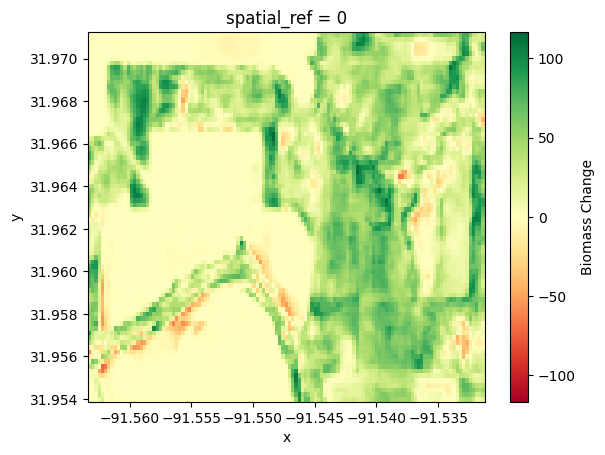

In [3]:
first_time = ds.isel(time=0)
last_time = ds.isel(time=-1)

aboveground_biomass_change = last_time['living_aboveground_biomass'] - first_time['living_aboveground_biomass']

aboveground_biomass_change.plot(cmap='RdYlGn', center=0, 
                     cbar_kwargs={'label': 'Biomass Change'})

### Threshold-based change detection

The plots above show all change, but much of the AOI has only slight change. An alternative approach is to set some threshold and flag any changes that exceed this threshold. In the example below, we'll calculate the change between 2022 and 2023 and then threshold to show only areas with more than 30% change. 

Text(0.5, 1.0, 'Areas with >30% Biomass Change')

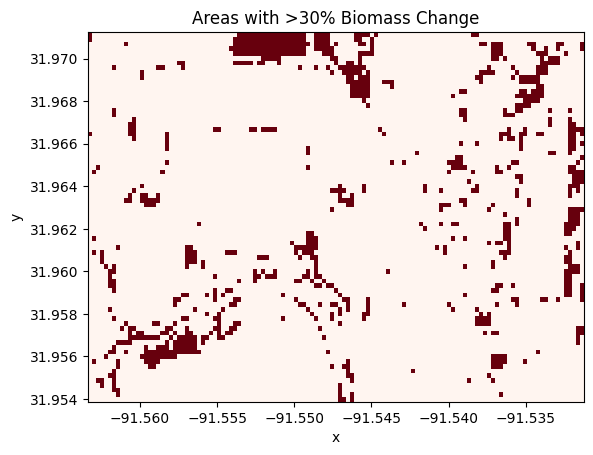

In [4]:
# Calculate change between 2022 and 2023
aboveground_biomass_change_2022_2023 = ds['living_aboveground_biomass'].sel(time='2023-07-01') - ds['living_aboveground_biomass'].sel(time='2022-07-01')

# First calculate the percent change relative to the starting biomass value. 
percent_change = (aboveground_biomass_change_2022_2023 / ds['living_aboveground_biomass'].sel(time='2022')) * 100
above_threshold_change = abs(percent_change) > 30

# Plot results
above_threshold_change.plot(cmap='Reds', add_colorbar=False)
plt.title('Areas with >30% Biomass Change')


### Calculate the rate of change

The [`.polyfit()`](https://docs.xarray.dev/en/stable/generated/xarray.DataArray.polyfit.html#xarray.DataArray.polyfit) function calculates the least squares polynomial fit to look at the rate of change over time. In the example below, we choose `deg=1` to fit a line to the change through time, and then select the first degree from the newly created 'polyfit_coefficients' variable which contains the rate of change. 

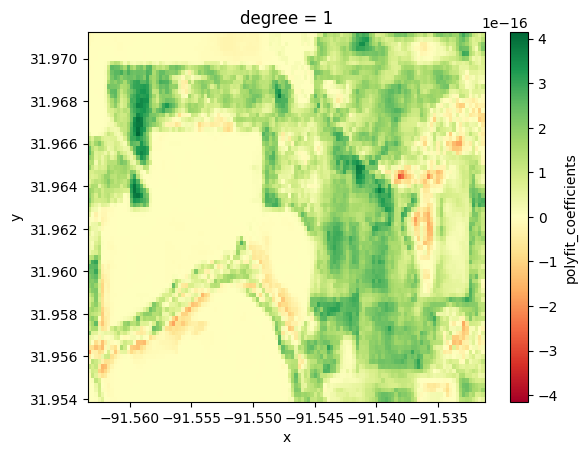

In [5]:
biomass_trend = ds['living_aboveground_biomass'].polyfit(dim='time', deg=1)['polyfit_coefficients'].sel(degree=1)
biomass_trend.plot(cmap='RdYlGn', center=0)

### Examine correlation between change of two variables

To look at the relationship between two variables, we can calculate the change of both aboveground biomass and canopy cover. Plotting these two variables on a scatter plot can give an indication of how closely correlated they are. 

Text(0, 0.5, 'Canopy Cover Change')

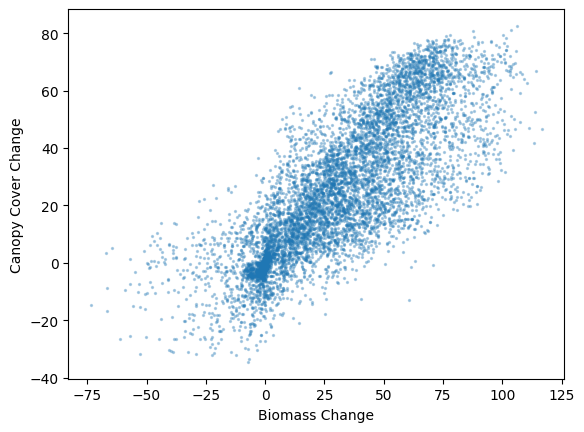

In [6]:
aboveground_biomass_change = last_time['living_aboveground_biomass'] - first_time['living_aboveground_biomass']
canopy_cover_change = last_time['canopy_cover'] - first_time['canopy_cover']

plt.scatter(aboveground_biomass_change.values.flatten(), 
            canopy_cover_change.values.flatten(), 
            alpha=0.3, s=2)
plt.xlabel('Biomass Change')
plt.ylabel('Canopy Cover Change')